In [ ]:
# Laboratorio 9: Datos sintéticos
- ¿Por qué una empresa podría no compartir sus datos reales?
- ¿Qué sesgos existen al utilizar información personal del cliente?
- ¿

In [8]:
# Importar librerias
from faker import Faker
import pandas as pd
import random

In [7]:
!pip install faker


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------------

In [10]:
# Cream,os una instancia de Faker
faker = Faker ("es_MX")

In [12]:
# Generar datos sinteticos: 100 registros
datos = []
for i in range (100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": faker.name(),
        "correo": faker.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint (100, 50000),
        "plataforma": random.choice(
            ["TikTok", "Instagram", "YouTube"]
        )
    })

In [14]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Conchita Macías Segovia,catalinamenchaca@example.net,53,40929,TikTok
1,2,Natalia Carbajal,eguerrero@example.com,42,47876,TikTok
2,3,Itzel Dávila Limón,zvalle@example.org,57,2967,TikTok
3,4,Verónica Jaqueline Solís Garza,renteriaespartaco@example.com,18,12837,Instagram
4,5,Teodoro Javier Concepción Zelaya,bde-jesus@example.com,54,7595,Instagram


In [15]:
#Exploración del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [31]:
#Estadistica descriptiva
df.describe()

,id_usuario,edad,seguidores
count,100.000000,100.000000,100.000000
mean,50.500000,42.050000,23122.720000
std,29.011492,14.205828,14399.391608
min,1.000000,18.000000,430.000000
25%,25.750000,30.000000,9894.500000
50%,50.500000,43.000000,21584.000000
75%,75.250000,53.250000,37089.000000
max,100.000000,65.000000,47876.000000


In [17]:
#Importar librerias para graficar
import seaborn as sns 
import matplotlib.pyplot as plt

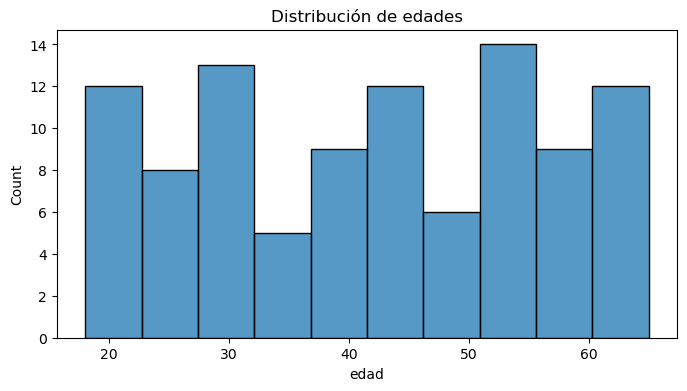

In [19]:
#Distribución de edades
plt.figure(figsize = (8,4))
sns.histplot(
    df["edad"],
    bins = 10
)
plt.title("Distribución de edades")
plt.show()

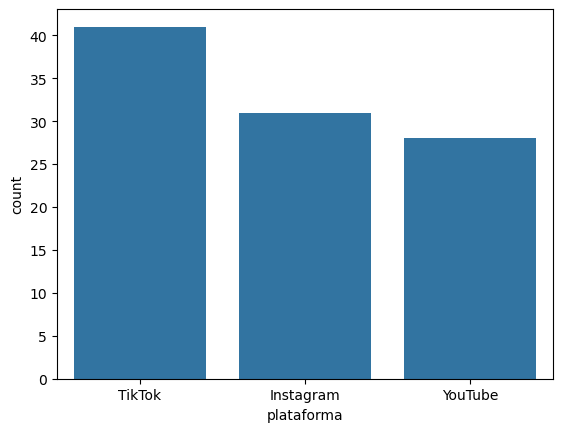

In [20]:
#Usuarios por plataforma
sns.countplot(
    x = "plataforma",
    data = df
)
plt.show()

In [21]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [22]:
#Le colocamos los valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None


In [23]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [24]:
#Edades inválidas 
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [25]:
df_sucio.describe()["edad"]

count    100.000000
mean      39.850000
std       17.899481
min      -10.000000
25%       29.000000
50%       42.500000
75%       53.000000
max       65.000000
Name: edad, dtype: float64

In [27]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [28]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.717121e+05
std      1.090297e+06
min      4.300000e+02
25%      1.001950e+04
50%      2.419200e+04
75%      3.732650e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [29]:
#Generamos correos inválidos 
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [32]:
df_sucio.describe(include = ["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Natalia Carbajal,correo_invalido,TikTok
freq,1,5,41


In [33]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [35]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [36]:
#Estadísticas
df_sucio.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Natalia Carbajal,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,5,NaN,NaN,41
mean,50.50,NaN,NaN,39.85,271712.13,NaN
std,29.01,NaN,NaN,17.90,1090296.51,NaN
min,1.00,NaN,NaN,-10.00,430.00,NaN
25%,25.75,NaN,NaN,29.00,10019.50,NaN
50%,50.50,NaN,NaN,42.50,24192.00,NaN
75%,75.25,NaN,NaN,53.00,37326.50,NaN
